### PCA - Principal Component Analysis

Very useful in noise/redundancy reduction => reduce amount of variables by creating hybrid variables (principal components).

You can also use clustering in order to visualize how easily separated the data is. 

In [23]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# load data 
df = pd.read_csv("winequality-red.csv")
df = df.drop_duplicates()

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5


In [24]:
len(df.columns)

12

### Scale the values and perform PCA on our data (X/y)

Explained variance ratio with 8 components, by each component:
[0.28293989 0.17347505 0.14066813 0.11368012 0.08735304 0.05796439
 0.05335491 0.03746183]

Explained variance ratio with 8 components, total result:
0.9468973630190098

Mean Squared Error (MSE) between original and reconstructed data:
0.05310263698099025
Average MSE per feature: 0.004828


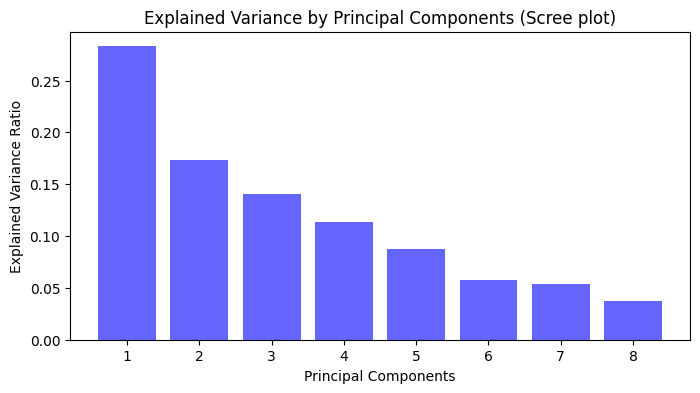

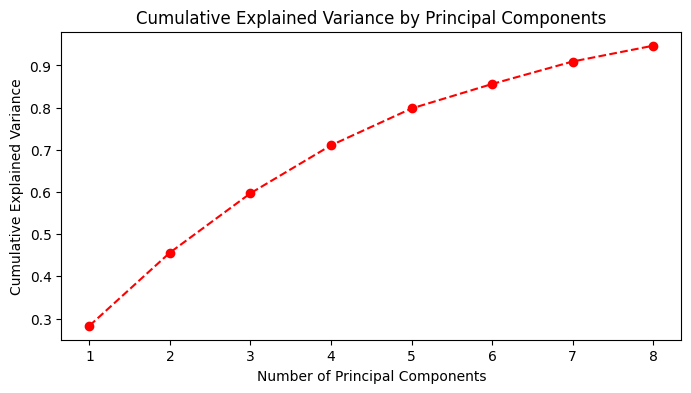

In [25]:
# X/y -split and scale the values
X = df.drop("quality", axis=1)
y = df['quality']

# scaling is needed in PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# define amount of PCA-variables => principal components
num_components = 8

# train the PCA -model
pca = PCA(n_components=num_components)
X_pca = pca.fit_transform(X_scaled)

# some basic metrics
explained_variance_ratio = pca.explained_variance_ratio_

print(f"Explained variance ratio with {num_components} components, by each component:\n{explained_variance_ratio}")
print(f"\nExplained variance ratio with {num_components} components, total result:\n{sum(explained_variance_ratio)}")

# 0.798 ~~ 80% of data preserved, which means we lost 20% of variance in the process
# aim to have less than 10% lost, or even less than 5% lost

X_reconstructed = pca.inverse_transform(X_pca)

# other metric is MSE => keep this as close to 0 as possible
# basically measures how much error the PCA model makes compared to original data
mse = mean_squared_error(X_scaled, X_reconstructed)
print(f"\nMean Squared Error (MSE) between original and reconstructed data:\n{mse}")
print(f"Average MSE per feature: {mse / X_scaled.shape[1]:.6f}")

# plot variance plots to see how much different components add to explainability
# plot 1: SCREE PLOT
plt.figure(figsize=(8, 4))
plt.bar(range(1, num_components + 1, ), explained_variance_ratio, alpha=0.6, color="b")
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance by Principal Components (Scree plot)")
plt.show()

# plot 2: cumulative explained variance
cumulative_variance = explained_variance_ratio.cumsum()
plt.figure(figsize=(8, 4))
plt.plot(range(1, num_components + 1, ), cumulative_variance, marker="o", linestyle='--', color="r")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance by Principal Components")
plt.show()

In [26]:
# get the component loadings
loadings = pca.components_

# create a DataFrame
loadings_df = pd.DataFrame(
    loadings.T,
    columns=[f"PC{i + 1}" for i in range(loadings.shape[0])], index=X.columns
)

In [27]:
loadings_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
fixed acidity,0.485314,-0.111220,-0.128634,-0.235668,-0.087802,-0.107940,0.361534,0.162757
volatile acidity,-0.239395,0.276474,-0.443882,0.072777,0.251819,-0.419938,0.520927,0.064335
citric acid,0.462539,-0.155371,0.236545,-0.074551,-0.054695,-0.071963,-0.097930,0.386750
residual sugar,0.134402,0.237869,0.114266,-0.405160,0.738541,-0.012261,-0.300662,-0.264735
chlorides,0.214132,0.130783,-0.092317,0.653842,0.285699,-0.276412,-0.358134,0.378456
free sulfur dioxide,-0.023138,0.512461,0.436809,-0.022181,-0.160125,0.030358,0.154502,0.208262
total sulfur dioxide,0.036027,0.576338,0.327314,-0.028156,-0.178251,-0.159682,0.068147,-0.037807
density,0.391745,0.230628,-0.349774,-0.179819,0.136141,0.402639,0.181961,0.225938
pH,-0.444253,0.002242,0.055122,-0.002776,0.232005,0.537439,0.060555,0.547898
sulphates,0.250491,-0.054744,0.262850,0.540297,0.238350,0.375201,0.433570,-0.405314


<Axes: >

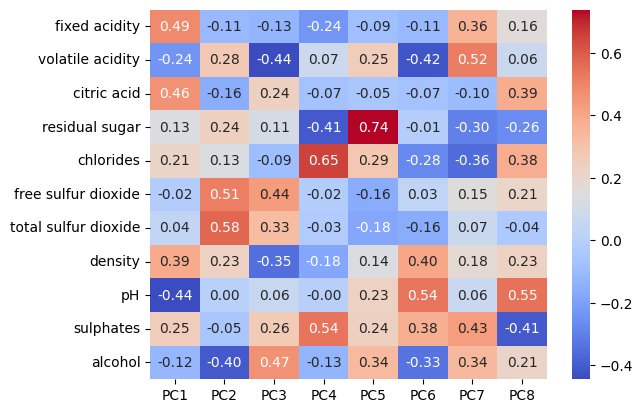

In [28]:
sns.heatmap(loadings_df, annot=True, fmt=".2f", cmap="coolwarm")

<b>Data Analysis - point of view -> finding noise etc.</b>

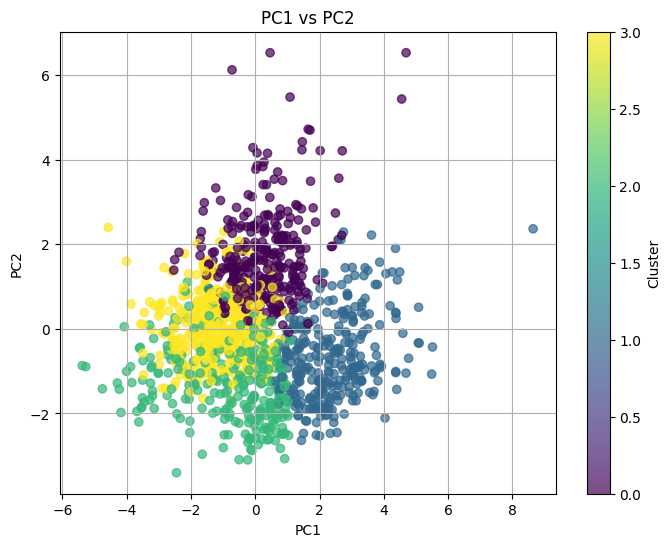

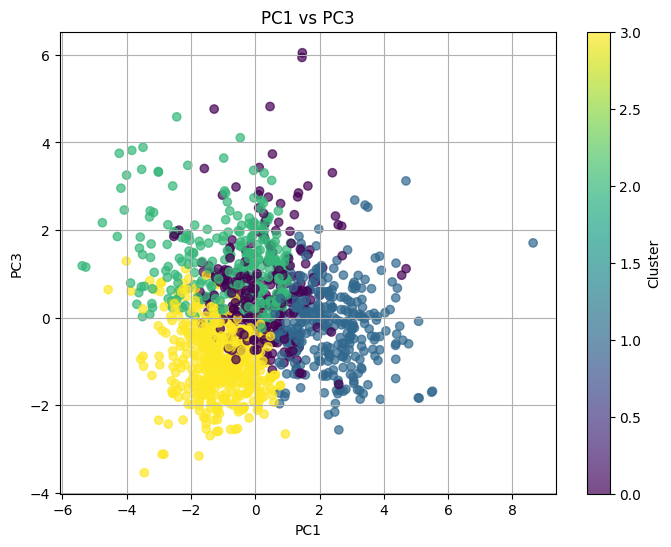

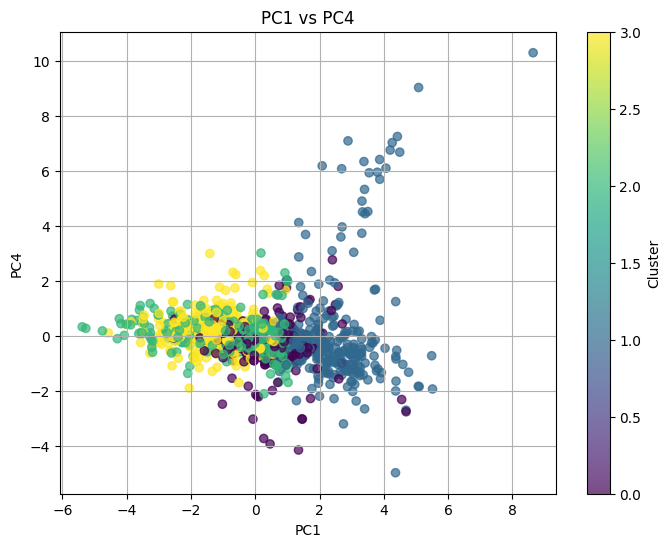

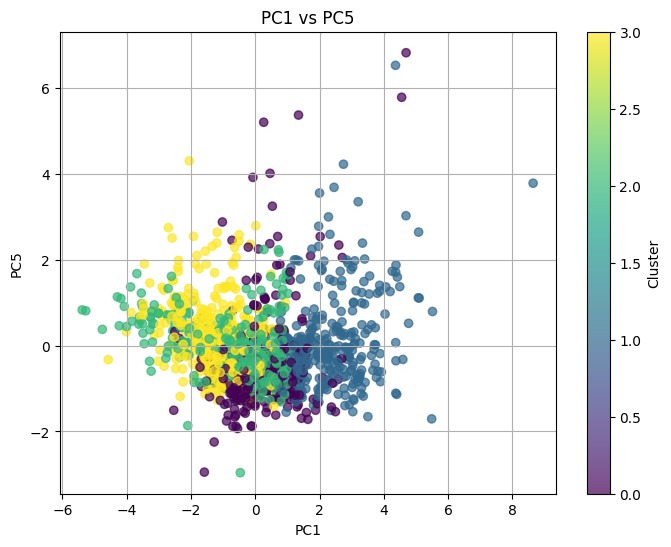

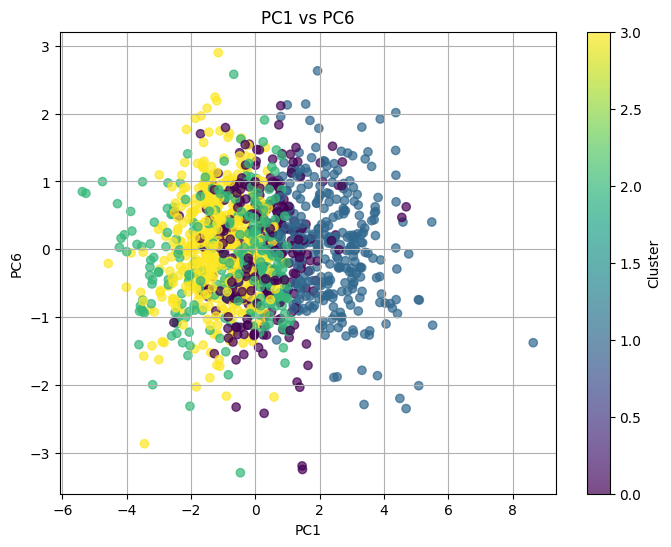

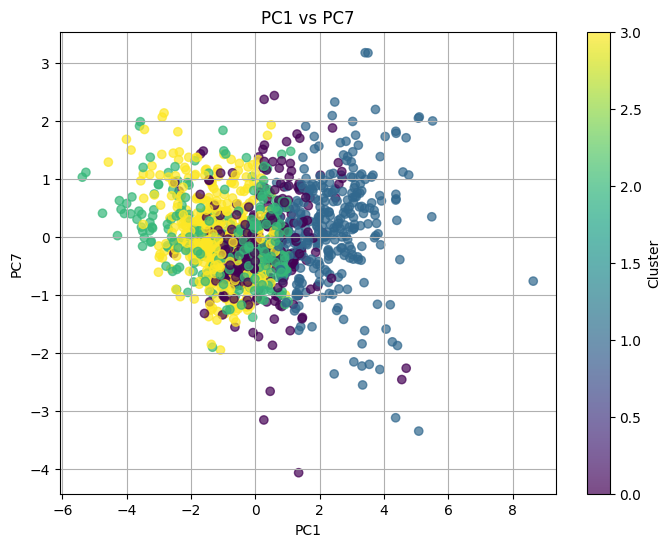

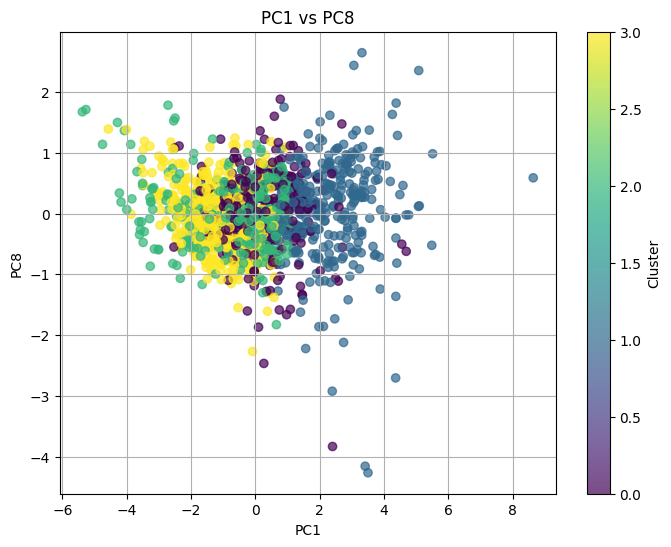

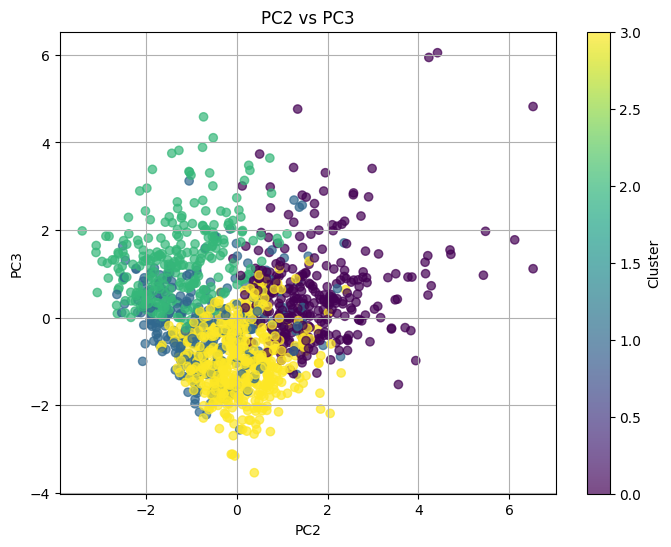

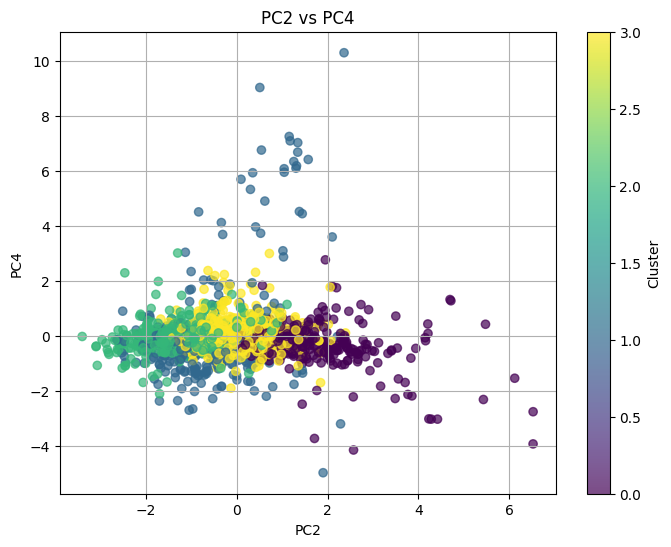

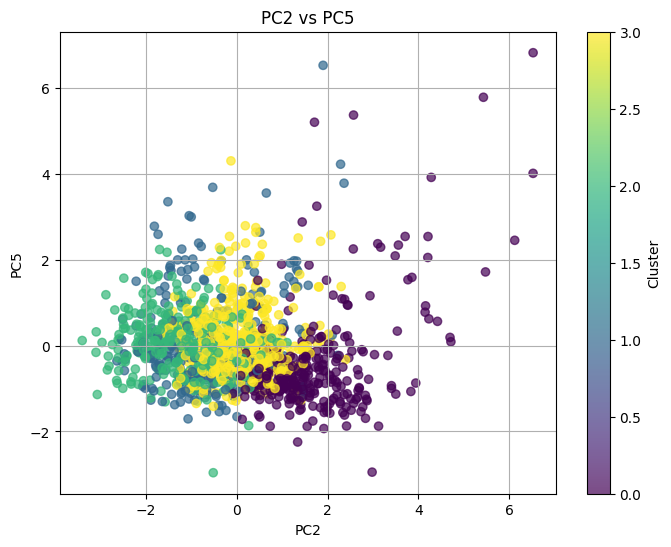

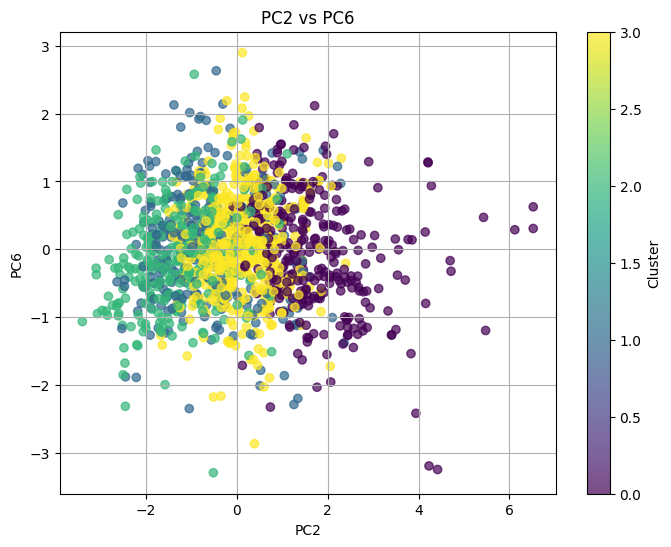

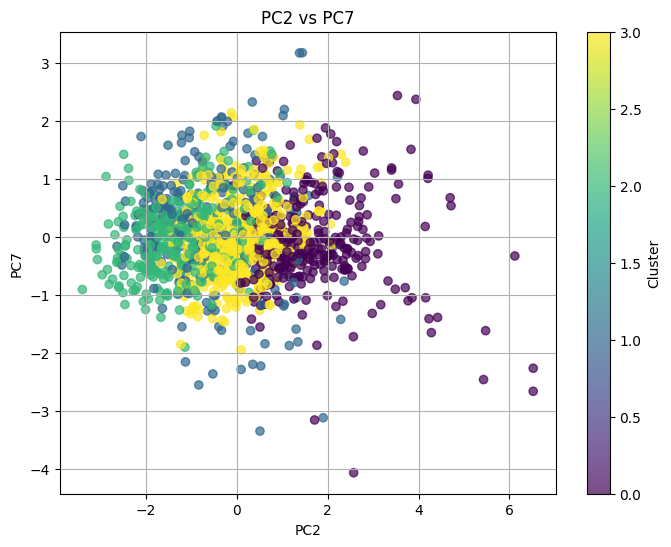

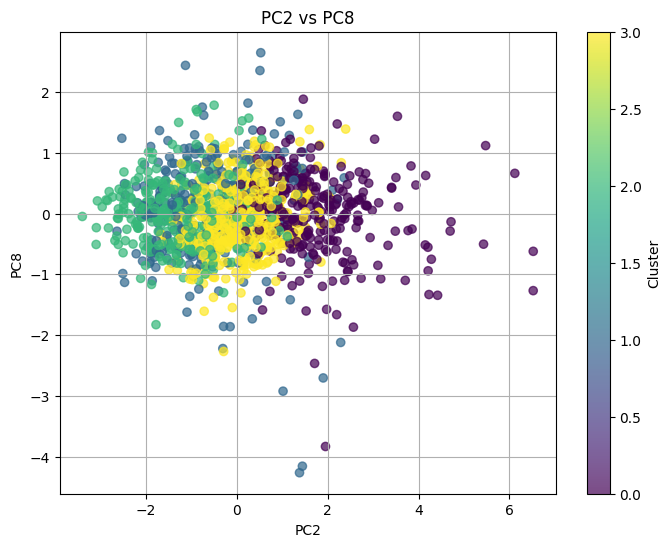

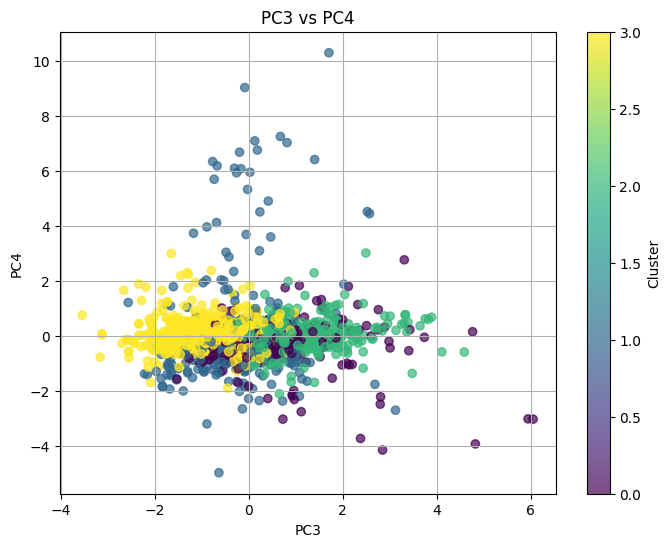

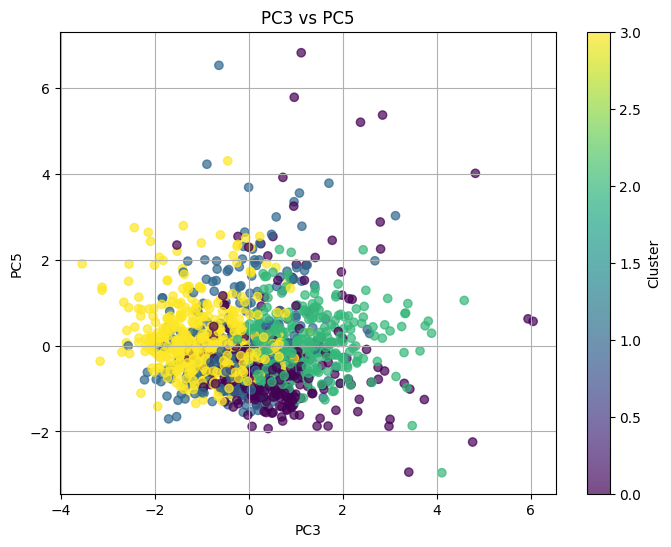

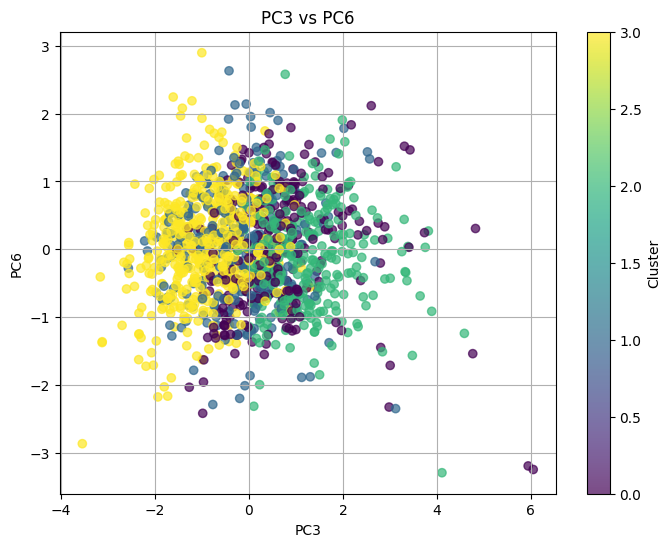

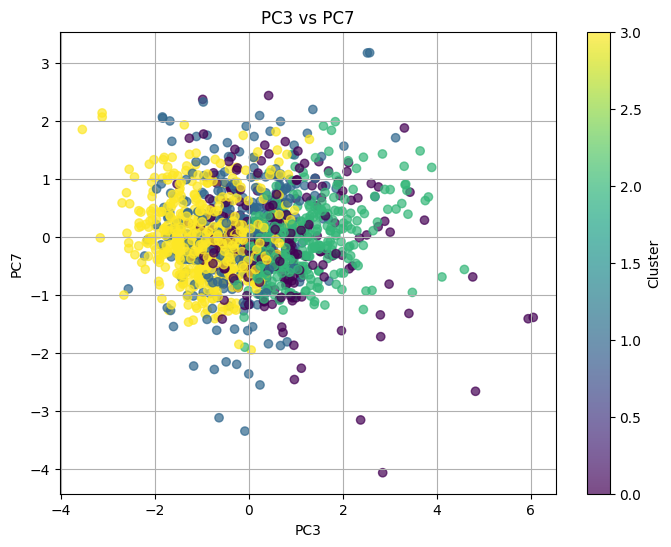

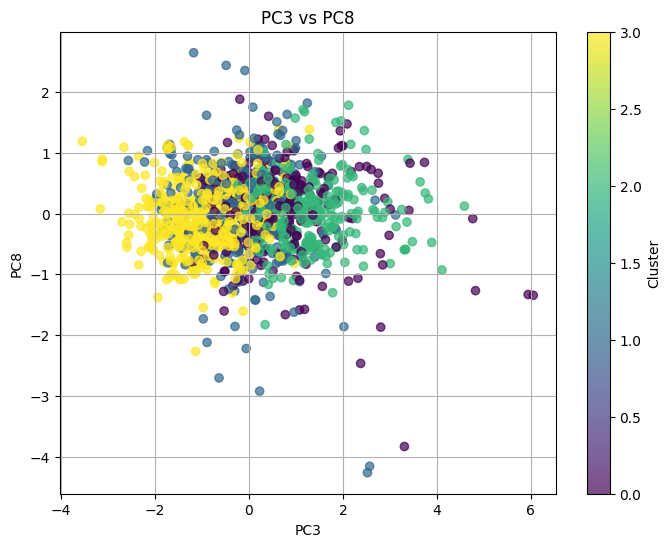

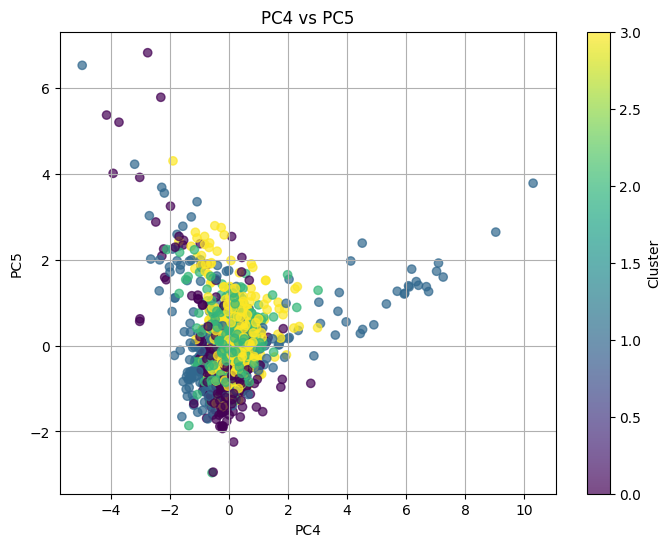

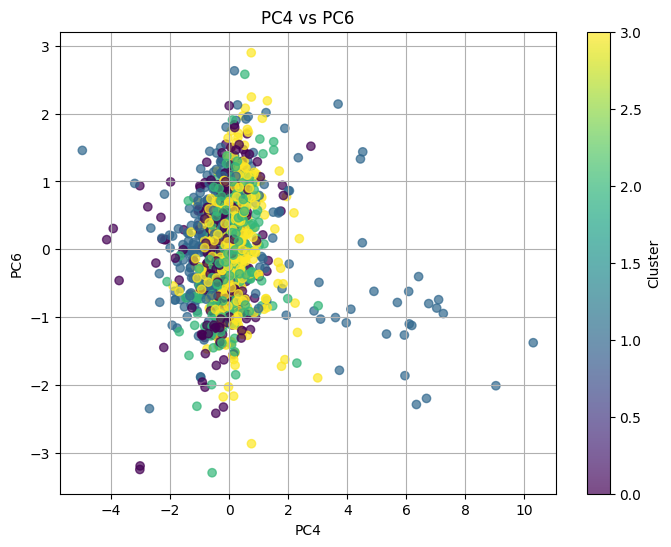

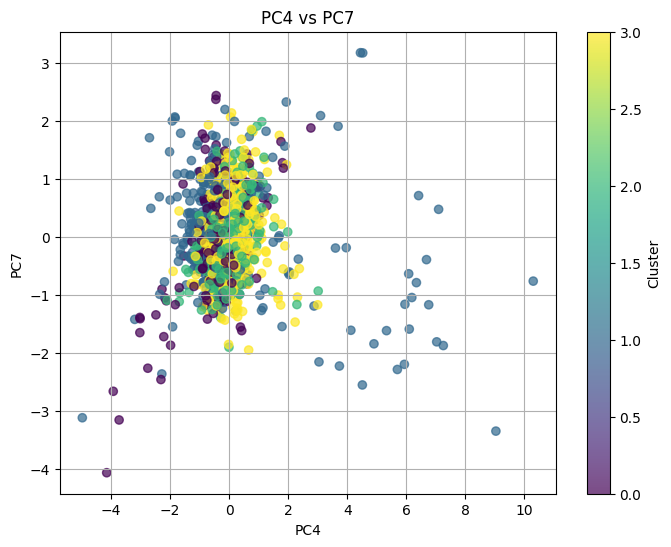

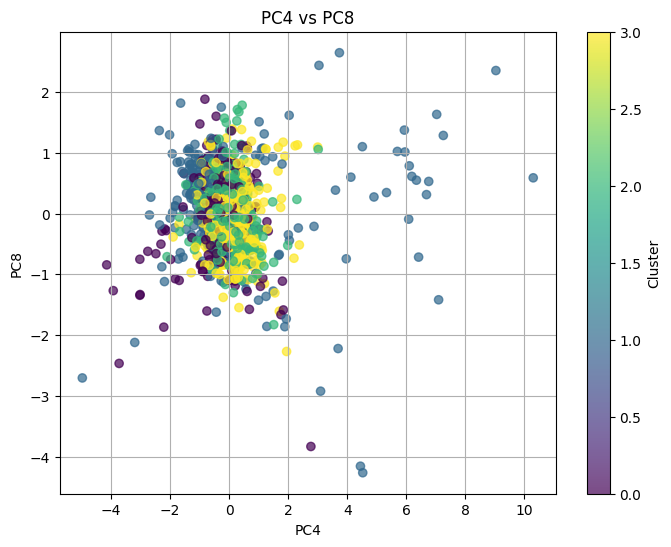

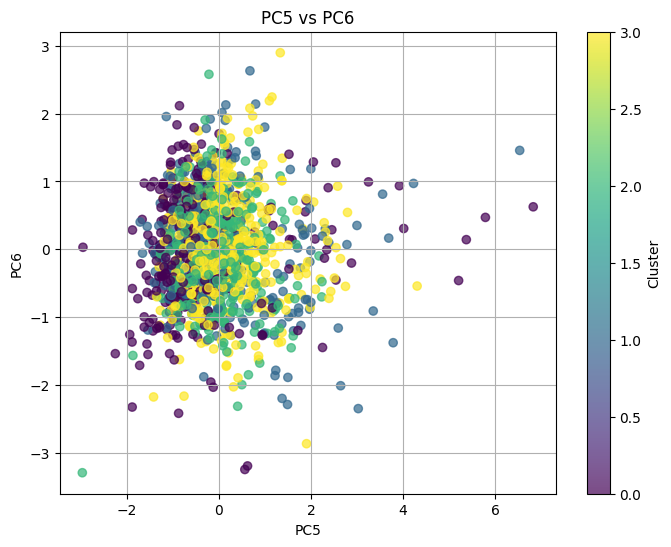

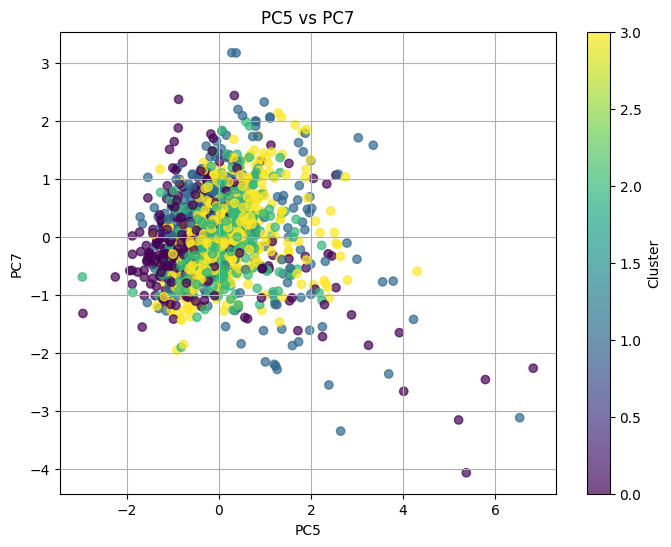

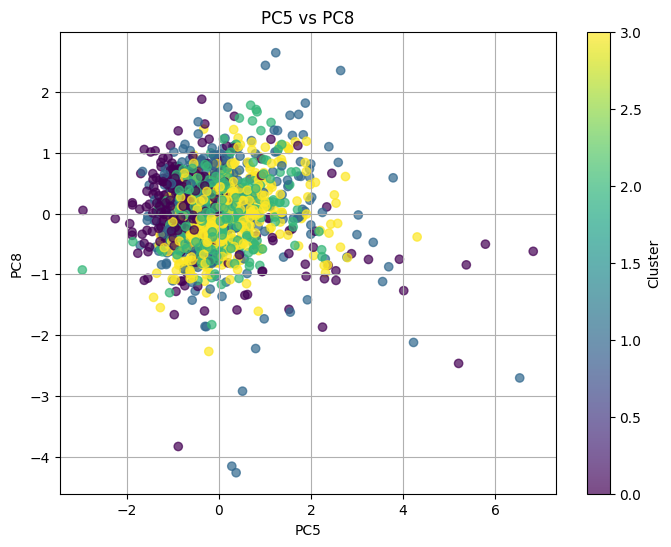

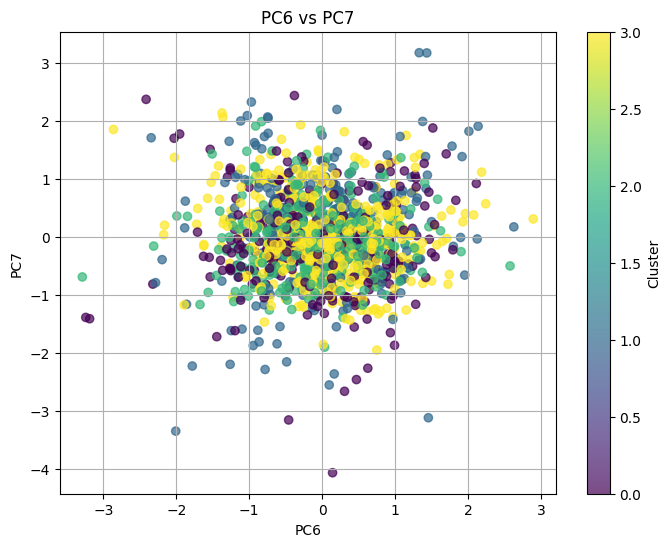

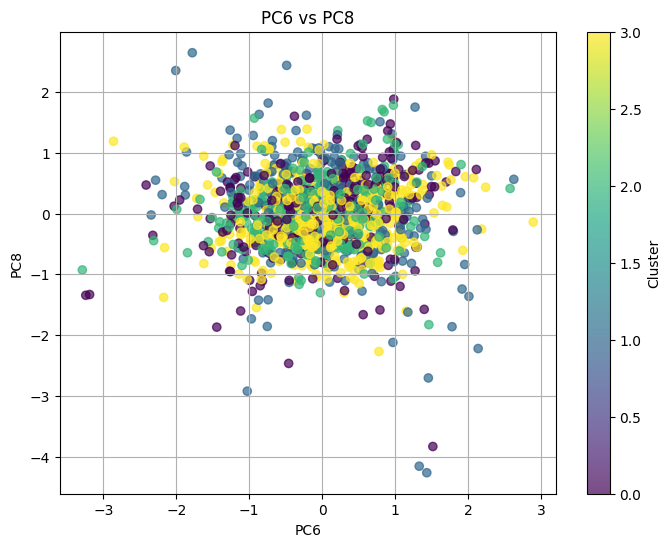

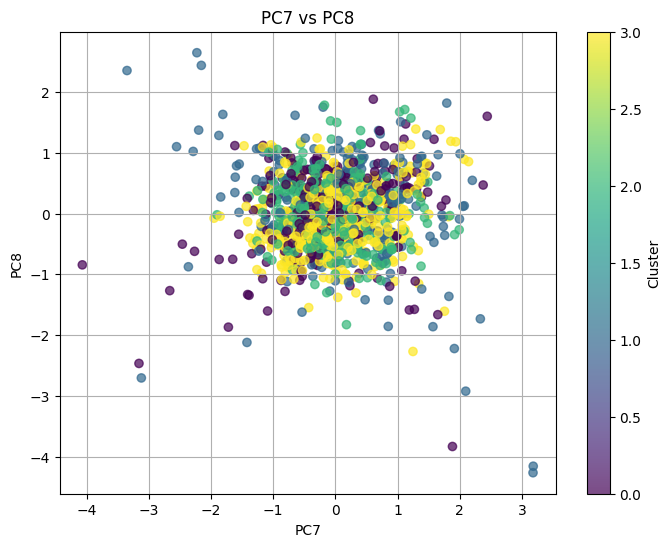

In [29]:
# helper function to compare and visualize PC-variables


def plot_pca_pairs(pca_result, components):
    num_c = pca_result.shape[1]

    # process each pair of PC-variables
    for i in range(num_c):
        for j in range(i + 1, num_c):
            plt.figure(figsize=(8, 6))
            plt.scatter(pca_result[:, i], pca_result[:, j], alpha=0.7)
            plt.title(f"PC{i+1} vs PC{j+1}")
            plt.xlabel(f"PC{i+1}")
            plt.ylabel(f"PC{j+1}")
            plt.grid(True)
            plt.show()


def plot_pca_pairs_with_clustering(pca_result, components, n_clusters=3):
    num_c = pca_result.shape[1]
    
    # Apply KMeans clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(pca_result)
    
    # Process each pair of PC-variables and plot clusters
    for i in range(num_c):
        for j in range(i + 1, num_c):
            plt.figure(figsize=(8, 6))
            scatter = plt.scatter(pca_result[:, i], pca_result[:, j], c=cluster_labels, cmap='viridis', alpha=0.7)
            plt.title(f"PC{i+1} vs PC{j+1}")
            plt.xlabel(f"PC{i+1}")
            plt.ylabel(f"PC{j+1}")
            plt.grid(True)
            plt.colorbar(scatter, label='Cluster')
            plt.show()

# plot_pca_pairs(X_pca, pca.components_)
# we can also use KMeans to visualize how well the data can be differentiated
# 3 is a good number to begin with for clusters, try also 6 (amount of options in the target)
plot_pca_pairs_with_clustering(X_pca, pca.components_, n_clusters=4)
